# ECGR 5106 Homework 3

Name: Omar Mina-Blanco

Student ID: 800863713


In [1]:
import os
import re
import math
import time
import random
import unicodedata
from collections import Counter
from dataclasses import dataclass
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility seed 42
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

USE_AMP = torch.cuda.is_available() #speed up for A100 gpu

In [2]:
@dataclass
class Config:
    dataset_path: str = "vast_english_french.txt"
    output_dir: str = "output"
    train_ratio: float = 0.80 #80/20 split
    max_pairs: int | None = None  # None for full dataset, set to speed up
    min_freq: int = 1 #min occurance of word to be added
    max_vocab_size: int | None = None # none for full size
    max_len: int = 30    # filters long sentence pairs for training
    batch_size: int = 128 #for sentence pairs, works for A100
    embedding_dim: int = 256 #more parameters
    hidden_size: int = 256 #remembers more, set to same as embedding
    num_layers: int = 1 #embedding -> GRU -> output
    dropout: float = 0.1 #droput for training
    learning_rate: float = 0.001 #default lr
    epochs: int = 50 #start at 10 and step up
    teach_value: float = 0.5 #probability of correct target word and its own previous prediction
    gradient_limit: float = 1.0 #limits gradient for stability
    num_workers: int = 2 #number of processes

cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)
cfg

Config(dataset_path='vast_english_french.txt', output_dir='output', train_ratio=0.8, max_pairs=None, min_freq=1, max_vocab_size=None, max_len=30, batch_size=128, embedding_dim=256, hidden_size=256, num_layers=1, dropout=0.1, learning_rate=0.001, epochs=50, teach_value=0.5, gradient_limit=1.0, num_workers=2)

In [3]:
from google.colab import drive
drive.mount('/content/drive')
cfg.dataset_path = '/content/drive/MyDrive/vast_english_french.txt'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def unicode_to_ascii(s): #converts accent characters for translating

    return ''.join(
        c for c in unicodedata.normalize('NFD', s) #NFD translates each character into its decomposed form.
        if unicodedata.category(c) != 'Mn' #Mark, Nonspacing, drpos accent marks
    )

#Convert to lowercase, removes extra spaces, converts to ASCII
def normalize_sentence(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?']+", r" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

#read both english and French
def read_two_language_dataset(path, max_pairs=None, max_len=None):
    pairs = [] #initiates pairs
    skipped = 0 #initiates bad lines to skip

    with open(path, "r", encoding="utf-8") as f: #Opens the dataset file using UTF-8
        for line in f:
            line = line.strip() #reads lines and removes extra spaces
            if not line:
                continue

            # datasets use tab separated fields, this splits for each pair
            parts = line.split("\t")
            if len(parts) < 2:
                skipped += 1
                continue

            eng = normalize_sentence(parts[0])
            fra = normalize_sentence(parts[1])

            if not eng or not fra: #does not count empty pairs
                skipped += 1
                continue

            if max_len is not None: #uses the sentence limit
                if len(eng.split()) > max_len or len(fra.split()) > max_len:
                    skipped += 1
                    continue

            pairs.append((eng, fra)) #adds formated pairs to dataset

            if max_pairs is not None and len(pairs) >= max_pairs:
                break

    print(f"Loaded {len(pairs)} sentence pairs. Skipped {skipped} lines.")
    return pairs

pairs = read_two_language_dataset(cfg.dataset_path, max_pairs=cfg.max_pairs, max_len=cfg.max_len)
print("Example pair:")
print(pairs[0])

Loaded 555 sentence pairs. Skipped 0 lines.
Example pair:
('i am cold', "j'ai froid")


In [5]:
indices = list(range(len(pairs))) #row numbers for every sentence pair.
random.Random(SEED).shuffle(indices)

train_size = int(cfg.train_ratio * len(indices))
train_indices = indices[:train_size] #first 80%
val_indices = indices[train_size:] #last 20%

train_pairs = [pairs[i] for i in train_indices]
val_pairs = [pairs[i] for i in val_indices]

print("total pairs:", len(pairs))
print("training pairs:", len(train_pairs))
print("validation pairs:", len(val_pairs))
print("training ratio:", len(train_pairs) / len(pairs))

total pairs: 555
training pairs: 444
validation pairs: 111
training ratio: 0.8


In [6]:
#special tokens
PAD_TOKEN = "<pad>" #padding
SOS_TOKEN = "<sos>" #start of sentence
EOS_TOKEN = "<eos>" #end of sentence
UNK_TOKEN = "<unk>" #unknown

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

#builds vocabulary from sentences
class Vocab:
    def __init__(self, sentences, min_freq=1, max_size=None): #counts how many times every word appears
        counter = Counter()
        for sentence in sentences:
            counter.update(sentence.split())

        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN] #index to string

        words = [w for w, c in counter.most_common() if c >= min_freq] #keeps words that appear min_freq times.
        if max_size is not None:
            words = words[:max(0, max_size - len(self.itos))]

        self.itos.extend(words)
        self.stoi = {w: i for i, w in enumerate(self.itos)} #string to index

    def __len__(self): #gets vocabulary size
        return len(self.itos)

    def encode(self, sentence, add_eos=True):#converts to tokens
        ids = [self.stoi.get(w, UNK_IDX) for w in sentence.split()]
        if add_eos:
            ids.append(EOS_IDX)
        return ids

    def decode(self, ids, stop_at_eos=True): #token to words
        words = []
        for idx in ids:
            idx = int(idx)
            if stop_at_eos and idx == EOS_IDX:
                break
            if idx in [PAD_IDX, SOS_IDX]:
                continue
            words.append(self.itos[idx] if idx < len(self.itos) else UNK_TOKEN)
        return " ".join(words)
#vocabulary for english and french
eng_vocab = Vocab([eng for eng, fra in train_pairs], min_freq=cfg.min_freq, max_size=cfg.max_vocab_size)
fra_vocab = Vocab([fra for eng, fra in train_pairs], min_freq=cfg.min_freq, max_size=cfg.max_vocab_size)
print("English vocab size:", len(eng_vocab))
print("French vocab size:", len(fra_vocab))

English vocab size: 893
French vocab size: 993


In [7]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab, reverse=False):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.reverse = reverse

    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        eng, fra = self.pairs[idx]
#if french to english
        if self.reverse:
            src_sentence = fra
            trg_sentence = eng
#in english to french
        else:
            src_sentence = eng
            trg_sentence = fra
#converts words into token and adds <eos>
        src_ids = self.src_vocab.encode(src_sentence, add_eos=True)
        trg_ids = self.trg_vocab.encode(trg_sentence, add_eos=True)

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(trg_ids, dtype=torch.long), src_sentence, trg_sentence

#pytorch needs rectangular tensors
def pad_sequences(sequences, pad_value=PAD_IDX):
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    max_len = max(lengths).item()
    batch = torch.full((len(sequences), max_len), pad_value, dtype=torch.long)
    for i, seq in enumerate(sequences):
        batch[i, :len(seq)] = seq
    return batch, lengths #stores original size

def combine_translation(batch):
    src_seqs, trg_seqs, src_texts, trg_texts = zip(*batch)
    src_batch, src_lengths = pad_sequences(src_seqs)
    trg_batch, trg_lengths = pad_sequences(trg_seqs)
    return src_batch, src_lengths, trg_batch, trg_lengths, list(src_texts), list(trg_texts) #both tensors and text

def make_loaders(reverse=False):
    if reverse:
        src_vocab, trg_vocab = fra_vocab, eng_vocab
    else:
        src_vocab, trg_vocab = eng_vocab, fra_vocab

    train_ds = TranslationDataset(train_pairs, src_vocab, trg_vocab, reverse=reverse)
    val_ds = TranslationDataset(val_pairs, src_vocab, trg_vocab, reverse=reverse)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        collate_fn=combine_translation,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        collate_fn=combine_translation,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, val_loader, src_vocab, trg_vocab


train_loader_en_fr, val_loader_en_fr, src_vocab_en_fr, trg_vocab_en_fr = make_loaders(reverse=False)

print("English to French batch check:")
batch = next(iter(train_loader_en_fr))
print(batch[0].shape, batch[2].shape)
print(batch[4][0], "=", batch[5][0])


English to French batch check:
torch.Size([128, 10]) torch.Size([128, 13])
the thick snow is melting remarkably fast = la neige epaisse fond remarquablement vite


In [8]:
def ngram_counts(tokens, n): #counts groups of n consecutive words
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

#calculates BLEU-4 score for one sentence, smooth=1.0 avoids zero scores
def sentence_bleu4(reference, candidate, max_n=4, smooth=1.0):
    ref_tokens = reference.split()
    cand_tokens = candidate.split()

    if len(cand_tokens) == 0:
        return 0.0

    precisions = []
    for n in range(1, max_n + 1):
        ref_counts = ngram_counts(ref_tokens, n)
        cand_counts = ngram_counts(cand_tokens, n)

        if len(cand_counts) == 0:
            precisions.append(smooth / smooth)
            continue

        overlap = 0
        total = 0
        for gram, count in cand_counts.items():
            overlap += min(count, ref_counts.get(gram, 0))
            total += count

        precisions.append((overlap + smooth) / (total + smooth))

    if len(cand_tokens) > len(ref_tokens):
        brevity_penalty = 1.0 #penalty for to short translation
    else:
        brevity_penalty = math.exp(1 - len(ref_tokens) / max(1, len(cand_tokens)))
#caluclates using using mean and penalty
    log_precision = sum(math.log(p) for p in precisions) / max_n
    return brevity_penalty * math.exp(log_precision)
#exact match yes or no
def exact_match(reference, candidate):
    return int(reference.strip() == candidate.strip())

# Problem 1: Baseline Encoder-Decoder Architecture, English to French




In [9]:
class EncoderGRU(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=PAD_IDX) #embedding layer, word id to vector
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden


class DecoderGRU(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.output_size = output_size
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))
        output, hidden = self.gru(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden #predicts the next word

#combines the encoder and decoder into one model
class Seq2SeqBaseline(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size):
        super().__init__()
        self.encoder = EncoderGRU(src_vocab_size, cfg.embedding_dim, cfg.hidden_size, cfg.num_layers, cfg.dropout)
        self.decoder = DecoderGRU(trg_vocab_size, cfg.embedding_dim, cfg.hidden_size, cfg.num_layers, cfg.dropout)
        self.trg_vocab_size = trg_vocab_size

    def forward(self, src, trg=None, teach_value=0.5, max_len=None):
        batch_size = src.size(0)

        if trg is not None:
            max_len = trg.size(1)
        elif max_len is None:
            max_len = cfg.max_len + 5

        outputs = torch.zeros(batch_size, max_len, self.trg_vocab_size, device=src.device)
        _, hidden = self.encoder(src)

        input_token = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)

        for t in range(1, max_len):
            prediction, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = prediction

            use_teach = trg is not None and random.random() < teach_value
            top1 = prediction.argmax(dim=1)
            input_token = trg[:, t] if use_teach else top1

        return outputs

In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size(model):
    return count_parameters(model) * 4 / (1024 ** 2)

def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0

    for src, src_lengths, trg, trg_lengths, src_texts, trg_texts in loader:
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            output = model(src, trg, teach_value=cfg.teach_value)
            output_dim = output.shape[-1]

            # Ignore time 0 for SOS setup.
            loss = criterion(output[:, 1:, :].reshape(-1, output_dim), trg[:, 1:].reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.gradient_limit)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / max(1, len(loader))

def validate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for src, src_lengths, trg, trg_lengths, src_texts, trg_texts in loader:
            src = src.to(device)
            trg = trg.to(device)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                output = model(src, trg, teach_value=0.0)
                output_dim = output.shape[-1]
                loss = criterion(output[:, 1:, :].reshape(-1, output_dim), trg[:, 1:].reshape(-1))

            total_loss += loss.item()

    return total_loss / max(1, len(loader))


def translate_batch(model, src, trg_vocab, max_len=None, with_attention=False):
    model.eval()
    src = src.to(device)
    max_len = max_len or (cfg.max_len + 5)

    with torch.no_grad():
        if with_attention:
            outputs, attention = model(src, trg=None, teach_value=0.0, max_len=max_len, return_attention=True)
        else:
            outputs = model(src, trg=None, teach_value=0.0, max_len=max_len)
            attention = None

    pred_ids = outputs.argmax(dim=-1).cpu().tolist()
    pred_texts = [trg_vocab.decode(ids, stop_at_eos=True) for ids in pred_ids]
    return pred_texts, attention


def evaluate_generation(model, loader, trg_vocab, with_attention=False, max_batches=None):
    model.eval()
    exact_scores = []
    bleu_scores = []
    samples = []
    start = time.perf_counter()

    for batch_idx, (src, src_lengths, trg, trg_lengths, src_texts, trg_texts) in enumerate(loader):
        pred_texts, _ = translate_batch(model, src, trg_vocab, with_attention=with_attention)

        for src_text, trg_text, pred_text in zip(src_texts, trg_texts, pred_texts):
            em = exact_match(trg_text, pred_text)
            bleu = sentence_bleu4(trg_text, pred_text)
            exact_scores.append(em)
            bleu_scores.append(bleu)

            if len(samples) < 5:
                samples.append({
                    "source": src_text,
                    "target": trg_text,
                    "prediction": pred_text,
                    "exact_match": em,
                    "bleu4": bleu,
                })

        if max_batches is not None and batch_idx + 1 >= max_batches:
            break

    inference_time = time.perf_counter() - start
    return {
        "sequence_accuracy": sum(exact_scores) / max(1, len(exact_scores)),
        "bleu4": sum(bleu_scores) / max(1, len(bleu_scores)),
        "inference_time": inference_time,
        "samples": samples,
    }


def train_model(model, train_loader, val_loader, trg_vocab, experiment_name, with_attention=False):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {"train_loss": [], "val_loss": []}
    start = time.perf_counter()

    for epoch in range(1, cfg.epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss = validate_loss(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"{experiment_name} | epoch {epoch:02d}/{cfg.epochs} | train loss={train_loss:.4f} | val loss={val_loss:.4f}")

    training_time = time.perf_counter() - start
    gen_metrics = evaluate_generation(model, val_loader, trg_vocab, with_attention=with_attention)

    result = {
        "experiment": experiment_name,
        "train_loss": history["train_loss"][-1],
        "val_loss": history["val_loss"][-1],
        "sequence_accuracy": gen_metrics["sequence_accuracy"],
        "bleu4": gen_metrics["bleu4"],
        "training_time": training_time,
        "inference_time": gen_metrics["inference_time"],
        "params": count_parameters(model),
        "model_size": model_size(model),
        "history": history,
        "samples": gen_metrics["samples"],
    }

    return model, result

In [11]:
def plot_loss_curves(results, title, filename):
    plt.figure(figsize=(9, 5))
    for result in results:
        plt.plot(result["history"]["train_loss"], linestyle="--", label=result["experiment"] + " train")
        plt.plot(result["history"]["val_loss"], label=result["experiment"] + " val")
    plt.xlabel("Epoch")
    plt.ylabel("Cross entropy Loss")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(cfg.output_dir, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved", path)


def show_samples(result):
    rows = []
    for sample in result["samples"]:
        rows.append(sample)
    return pd.DataFrame(rows)


def save_samples_csv(result, filename):
    df = show_samples(result)
    path = os.path.join(cfg.output_dir, filename)
    df.to_csv(path, index=False)
    print("Saved", path)
    return df

In [12]:
baseline_en_fr = Seq2SeqBaseline(len(src_vocab_en_fr), len(trg_vocab_en_fr))
baseline_en_fr, result_baseline_en_fr = train_model(
    baseline_en_fr,
    train_loader_en_fr,
    val_loader_en_fr,
    trg_vocab_en_fr,
    experiment_name="P1 Baseline GRU English to French",
    with_attention=False,
)

pd.DataFrame([{k: v for k, v in result_baseline_en_fr.items() if k not in ["history", "samples"]}])

/tmp/ipykernel_29105/4031385851.py:110: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_29105/4031385851.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


P1 Baseline GRU English to French | epoch 01/50 | train loss=6.8474 | val loss=6.6517


/tmp/ipykernel_29105/4031385851.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


P1 Baseline GRU English to French | epoch 02/50 | train loss=6.4461 | val loss=5.9954
P1 Baseline GRU English to French | epoch 03/50 | train loss=5.8795 | val loss=5.9665
P1 Baseline GRU English to French | epoch 04/50 | train loss=5.5855 | val loss=5.9530
P1 Baseline GRU English to French | epoch 05/50 | train loss=5.3793 | val loss=5.8557
P1 Baseline GRU English to French | epoch 06/50 | train loss=5.2860 | val loss=5.8182
P1 Baseline GRU English to French | epoch 07/50 | train loss=5.1774 | val loss=5.8351
P1 Baseline GRU English to French | epoch 08/50 | train loss=5.1222 | val loss=5.8334
P1 Baseline GRU English to French | epoch 09/50 | train loss=4.9835 | val loss=5.8624
P1 Baseline GRU English to French | epoch 10/50 | train loss=4.9915 | val loss=5.8469
P1 Baseline GRU English to French | epoch 11/50 | train loss=4.8892 | val loss=5.8260
P1 Baseline GRU English to French | epoch 12/50 | train loss=4.8026 | val loss=5.8340
P1 Baseline GRU English to French | epoch 13/50 | trai

,experiment,train_loss,val_loss,sequence_accuracy,bleu4,training_time,inference_time,params,model_size
0,P1 Baseline GRU English to French,0.805574,6.054348,0.0,0.244279,13.922288,0.155874,1527521,5.82703


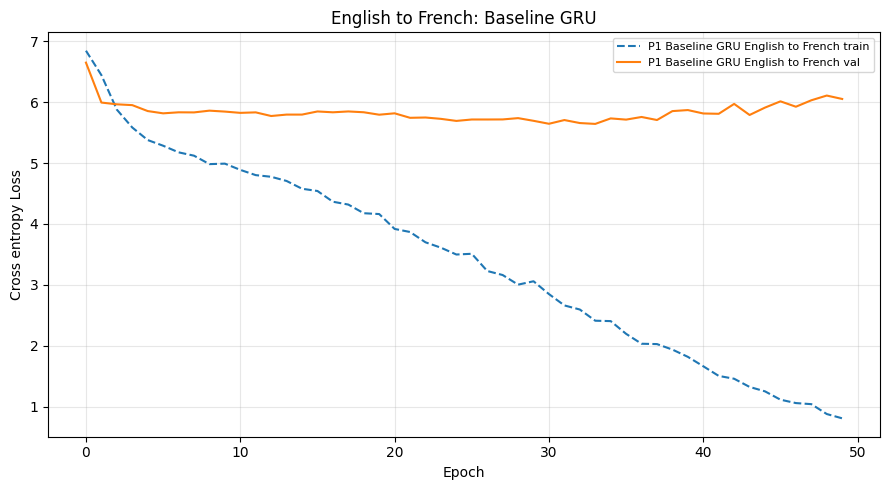

Saved output/p1_baseline_en_fr_loss_curves.png


In [13]:
plot_loss_curves(
    [result_baseline_en_fr],
    "English to French: Baseline GRU",
    "p1_baseline_en_fr_loss_curves.png",
)


In [14]:
show_samples(result_baseline_en_fr)

,source,target,prediction,exact_match,bleu4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,sommes perdus dans le parc,0,0.153889
1,she practices yoga every morning,elle pratique le yoga tous les matins,s'entrainent a la course tous les matins,0,0.345721
2,i enjoy walking in the snow,j'aime marcher dans la neige,sommes perdus dans le parc,0,0.273012
3,she loves to wear modern jackets,elle adore porter des vestes modernes,adore porter des vestes en cuir modernes,0,0.541082
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive precisement a cinq h...,train arrive a la a la fete,0,0.143900


# Problem 2: Sequence-to-Sequence with Attention, English to French


In [15]:
class LuongAttentionDecoderGRU(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.output_size = output_size
        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc_out = nn.Linear(hidden_size * 2, output_size)

    def forward(self, input_token, hidden, encoder_outputs, src_mask):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        decoder_output, hidden = self.gru(embedded, hidden)

        # Luong attention score(decoder hidden, encoder output) dot product.
        scores = torch.bmm(encoder_outputs, decoder_output.transpose(1, 2)).squeeze(2)

        scores = scores.masked_fill(src_mask == 0, float('-inf')) #float('-inf') instean of 1e-9
        attn_weights = torch.softmax(scores, dim=1)

        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        combined = torch.cat([decoder_output.squeeze(1), context], dim=1)
        prediction = self.fc_out(combined)

        return prediction, hidden, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size):
        super().__init__()
        self.encoder = EncoderGRU(src_vocab_size, cfg.embedding_dim, cfg.hidden_size, cfg.num_layers, cfg.dropout)
        self.decoder = LuongAttentionDecoderGRU(trg_vocab_size, cfg.embedding_dim, cfg.hidden_size, cfg.num_layers, cfg.dropout)
        self.trg_vocab_size = trg_vocab_size

    def forward(self, src, trg=None, teach_value=0.5, max_len=None, return_attention=False):
        batch_size = src.size(0)

        if trg is not None:
            max_len = trg.size(1)
        elif max_len is None:
            max_len = cfg.max_len + 5

        outputs = torch.zeros(batch_size, max_len, self.trg_vocab_size, device=src.device)
        attention_steps = []

        encoder_outputs, hidden = self.encoder(src)
        src_mask = (src != PAD_IDX)

        input_token = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)

        for t in range(1, max_len):
            prediction, hidden, attn_weights = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            outputs[:, t, :] = prediction
            attention_steps.append(attn_weights)

            use_teach = trg is not None and random.random() < teach_value
            top1 = prediction.argmax(dim=1)
            input_token = trg[:, t] if use_teach else top1

        if return_attention:
            attention_tensor = torch.stack(attention_steps, dim=1)
            return outputs, attention_tensor

        return outputs

# starts and train model
attention_en_fr = Seq2SeqAttention(len(src_vocab_en_fr), len(trg_vocab_en_fr))
attention_en_fr, result_attention_en_fr = train_model(
    attention_en_fr,
    train_loader_en_fr,
    val_loader_en_fr,
    trg_vocab_en_fr,
    experiment_name="P2 Attention GRU English to French",
    with_attention=True,
)

pd.DataFrame([{k: v for k, v in result_attention_en_fr.items() if k not in ["history", "samples"]}])

/tmp/ipykernel_29105/4031385851.py:110: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_29105/4031385851.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


P2 Attention GRU English to French | epoch 01/50 | train loss=6.8028 | val loss=6.3941


/tmp/ipykernel_29105/4031385851.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


P2 Attention GRU English to French | epoch 02/50 | train loss=6.1202 | val loss=5.8691
P2 Attention GRU English to French | epoch 03/50 | train loss=5.7268 | val loss=6.0934
P2 Attention GRU English to French | epoch 04/50 | train loss=5.4209 | val loss=5.8258
P2 Attention GRU English to French | epoch 05/50 | train loss=5.2651 | val loss=5.7524
P2 Attention GRU English to French | epoch 06/50 | train loss=5.0852 | val loss=5.8035
P2 Attention GRU English to French | epoch 07/50 | train loss=4.9269 | val loss=5.7826
P2 Attention GRU English to French | epoch 08/50 | train loss=4.7680 | val loss=5.6700
P2 Attention GRU English to French | epoch 09/50 | train loss=4.5685 | val loss=5.6360
P2 Attention GRU English to French | epoch 10/50 | train loss=4.3594 | val loss=5.6545
P2 Attention GRU English to French | epoch 11/50 | train loss=4.2355 | val loss=5.6147
P2 Attention GRU English to French | epoch 12/50 | train loss=3.9888 | val loss=5.5570
P2 Attention GRU English to French | epoch 

,experiment,train_loss,val_loss,sequence_accuracy,bleu4,training_time,inference_time,params,model_size
0,P2 Attention GRU English to French,0.143594,6.183241,0.0,0.267756,15.865677,0.12888,1781729,6.796757


In [16]:
show_samples(result_attention_en_fr)

,source,target,prediction,exact_match,bleu4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,nourrissent les canards dans le parc,0,0.246085
1,she practices yoga every morning,elle pratique le yoga tous les matins,a la course tous les matins,0,0.348017
2,i enjoy walking in the snow,j'aime marcher dans la neige,neige la tour dans le,0,0.324668
3,she loves to wear modern jackets,elle adore porter des vestes modernes,adore porter des vestes en cuir modernes,0,0.541082
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive precisement a cinq h...,bus arrive a cinq heures,0,0.206874


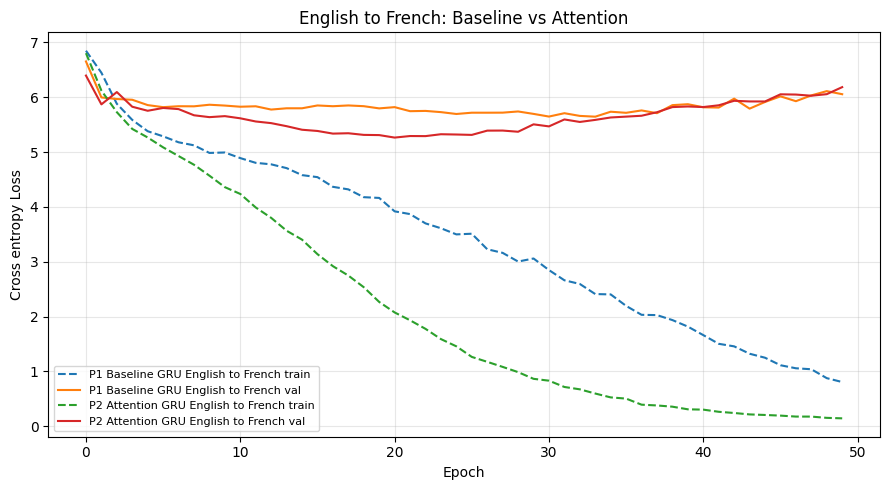

Saved output/en_fr_loss_curves.png


In [17]:
plot_loss_curves(
    [result_baseline_en_fr, result_attention_en_fr],
    "English to French: Baseline vs Attention",
    "en_fr_loss_curves.png",
)

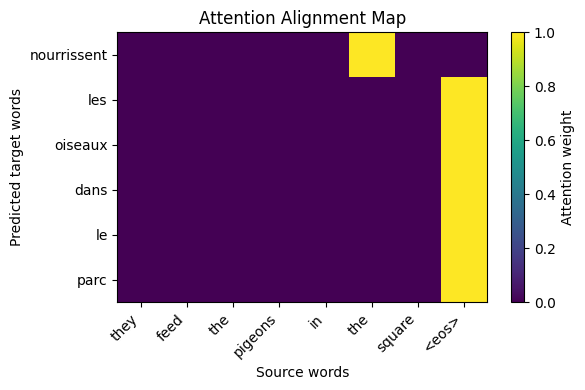

Source: they feed the pigeons in the square
Target: ils nourrissent les pigeons sur la place
Prediction: nourrissent les oiseaux dans le parc
Saved output/attention_en_fr_sample0.png


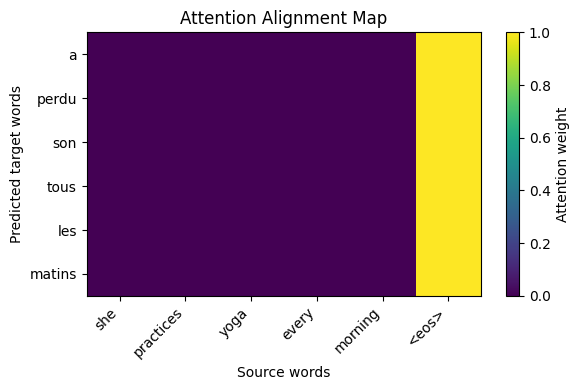

Source: she practices yoga every morning
Target: elle pratique le yoga tous les matins
Prediction: a perdu son tous les matins
Saved output/attention_en_fr_sample1.png


In [18]:
def plot_attention_map(model, dataset, src_vocab, trg_vocab, sample_index=0, filename="attention_map.png"):
    model.eval()
    src, trg, src_text, trg_text = dataset[sample_index]
    src_batch, _ = pad_sequences([src])
    pred_texts, attention = translate_batch(model, src_batch, trg_vocab, with_attention=True, max_len=cfg.max_len + 5)

    pred_tokens = pred_texts[0].split()
    src_tokens = src_text.split() + [EOS_TOKEN]

    if attention is None:
        print("No attention returned.")
        return

    attn = attention[0, :len(pred_tokens), :len(src_tokens)].detach().cpu().numpy()

    plt.figure(figsize=(max(6, len(src_tokens) * 0.55), max(4, len(pred_tokens) * 0.45)))
    plt.imshow(attn, aspect="auto", cmap="viridis")
    plt.colorbar(label="Attention weight")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
    plt.yticks(range(len(pred_tokens)), pred_tokens)
    plt.xlabel("Source words")
    plt.ylabel("Predicted target words")
    plt.title("Attention Alignment Map")
    plt.tight_layout()

    path = os.path.join(cfg.output_dir, filename)
    plt.savefig(path, dpi=150)
    plt.show()

    print("Source:", src_text)
    print("Target:", trg_text)
    print("Prediction:", pred_texts[0])
    print("Saved", path)

val_dataset_en_fr = TranslationDataset(val_pairs, src_vocab_en_fr, trg_vocab_en_fr, reverse=False)
plot_attention_map(attention_en_fr, val_dataset_en_fr, src_vocab_en_fr, trg_vocab_en_fr, sample_index=0, filename="attention_en_fr_sample0.png")
plot_attention_map(attention_en_fr, val_dataset_en_fr, src_vocab_en_fr, trg_vocab_en_fr, sample_index=1, filename="attention_en_fr_sample1.png")

# Problem 3: Reversing the Language Direction, French to English


In [19]:
train_loader_fr_en, val_loader_fr_en, src_vocab_fr_en, trg_vocab_fr_en = make_loaders(reverse=True)

print("French to English batch check:")
batch = next(iter(train_loader_fr_en))
print(batch[0].shape, batch[2].shape)
print(batch[4][0], "=", batch[5][0])


French to English batch check:
torch.Size([128, 13]) torch.Size([128, 10])
elle aime ecouter de la musique classique la nuit = she enjoys listening to classical music at night


In [20]:
baseline_fr_en = Seq2SeqBaseline(len(src_vocab_fr_en), len(trg_vocab_fr_en))
baseline_fr_en, result_baseline_fr_en = train_model(
    baseline_fr_en,
    train_loader_fr_en,
    val_loader_fr_en,
    trg_vocab_fr_en,
    experiment_name="P3 Baseline GRU French to English",
    with_attention=False,
)

attention_fr_en = Seq2SeqAttention(len(src_vocab_fr_en), len(trg_vocab_fr_en))
attention_fr_en, result_attention_fr_en = train_model(
    attention_fr_en,
    train_loader_fr_en,
    val_loader_fr_en,
    trg_vocab_fr_en,
    experiment_name="P3 Attention GRU French to English",
    with_attention=True,
)

/tmp/ipykernel_29105/4031385851.py:110: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_29105/4031385851.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_29105/4031385851.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


P3 Baseline GRU French to English | epoch 01/50 | train loss=6.7473 | val loss=6.5367
P3 Baseline GRU French to English | epoch 02/50 | train loss=6.3970 | val loss=5.9011
P3 Baseline GRU French to English | epoch 03/50 | train loss=5.7034 | val loss=5.7849
P3 Baseline GRU French to English | epoch 04/50 | train loss=5.3667 | val loss=5.7522
P3 Baseline GRU French to English | epoch 05/50 | train loss=5.2420 | val loss=5.7164
P3 Baseline GRU French to English | epoch 06/50 | train loss=5.0993 | val loss=5.7236
P3 Baseline GRU French to English | epoch 07/50 | train loss=5.0260 | val loss=5.7555
P3 Baseline GRU French to English | epoch 08/50 | train loss=4.9035 | val loss=5.7700
P3 Baseline GRU French to English | epoch 09/50 | train loss=4.7856 | val loss=5.8015
P3 Baseline GRU French to English | epoch 10/50 | train loss=4.8561 | val loss=5.7998
P3 Baseline GRU French to English | epoch 11/50 | train loss=4.6944 | val loss=5.8329
P3 Baseline GRU French to English | epoch 12/50 | trai

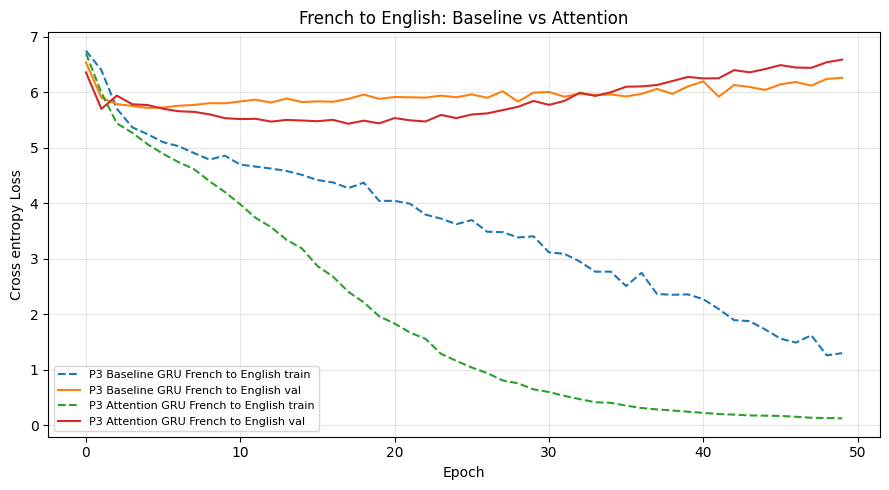

Saved output/fr_en_loss_curves.png


,source,target,prediction,exact_match,bleu4
0,ils nourrissent les pigeons sur la place,they feed the pigeons in the square,play volleyball on the weekends,0,0.183005
1,elle pratique le yoga tous les matins,she practices yoga every morning,practice piano every afternoon,0,0.279826
2,j'aime marcher dans la neige,i enjoy walking in the snow,enjoy walking in the park,0,0.622101
3,elle adore porter des vestes modernes,she loves to wear modern jackets,loves to wear modern,0,0.606531
4,le bus de la ville arrive precisement a cinq h...,the city bus arrives precisely at five o'clock,translates technical documents,0,0.085334


In [21]:
plot_loss_curves(
    [result_baseline_fr_en, result_attention_fr_en],
    "French to English: Baseline vs Attention",
    "fr_en_loss_curves.png",
)

show_samples(result_baseline_fr_en)

In [22]:
show_samples(result_attention_fr_en)

,source,target,prediction,exact_match,bleu4
0,ils nourrissent les pigeons sur la place,they feed the pigeons in the square,are going to the beach,0,0.183005
1,elle pratique le yoga tous les matins,she practices yoga every morning,practice running every morning,0,0.368272
2,j'aime marcher dans la neige,i enjoy walking in the snow,love walking in the forest,0,0.416024
3,elle adore porter des vestes modernes,she loves to wear modern jackets,loves to wear modern,0,0.606531
4,le bus de la ville arrive precisement a cinq h...,the city bus arrives precisely at five o'clock,left his five o'clock,0,0.173959


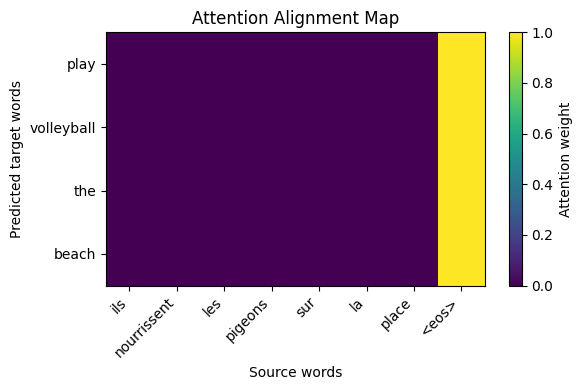

Source: ils nourrissent les pigeons sur la place
Target: they feed the pigeons in the square
Prediction: play volleyball the beach
Saved output/attention_fr_en_sample0.png


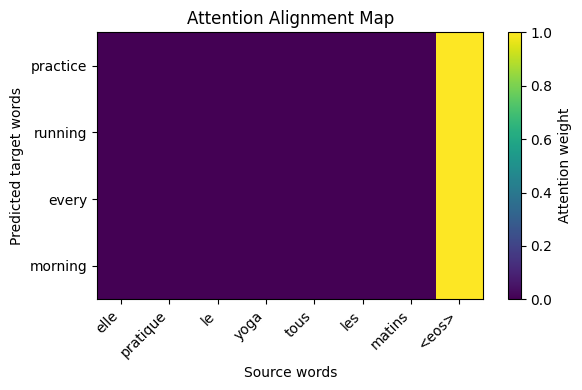

Source: elle pratique le yoga tous les matins
Target: she practices yoga every morning
Prediction: practice running every morning
Saved output/attention_fr_en_sample1.png


In [23]:
val_dataset_fr_en = TranslationDataset(val_pairs, src_vocab_fr_en, trg_vocab_fr_en, reverse=True)
plot_attention_map(attention_fr_en, val_dataset_fr_en, src_vocab_fr_en, trg_vocab_fr_en, sample_index=0, filename="attention_fr_en_sample0.png")
plot_attention_map(attention_fr_en, val_dataset_fr_en, src_vocab_fr_en, trg_vocab_fr_en, sample_index=1, filename="attention_fr_en_sample1.png")

In [24]:
all_results = [
    result_baseline_en_fr,
    result_attention_en_fr,
    result_baseline_fr_en,
    result_attention_fr_en,
]

summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["history", "samples"]}
    for r in all_results
])

summary_df = summary_df[[
    "experiment", "train_loss", "val_loss", "sequence_accuracy", "bleu4",
    "training_time", "inference_time", "params", "model_size"
]]

summary_df

,experiment,train_loss,val_loss,sequence_accuracy,bleu4,training_time,inference_time,params,model_size
0,P1 Baseline GRU English to French,0.805574,6.054348,0.0,0.244279,13.922288,0.155874,1527521,5.827030
1,P2 Attention GRU English to French,0.143594,6.183241,0.0,0.267756,15.865677,0.128880,1781729,6.796757
2,P3 Baseline GRU French to English,1.297582,6.259802,0.0,0.241152,13.238038,0.095366,1501821,5.728992
3,P3 Attention GRU French to English,0.122833,6.587141,0.0,0.249977,14.565122,0.104298,1730429,6.601063


In [25]:
summary_path = os.path.join(cfg.output_dir, "seq2seq_summary_results.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved", summary_path)

save_samples_csv(result_baseline_en_fr, "samples_baseline_en_fr.csv")
save_samples_csv(result_attention_en_fr, "samples_attention_en_fr.csv")
save_samples_csv(result_baseline_fr_en, "samples_baseline_fr_en.csv")
save_samples_csv(result_attention_fr_en, "samples_attention_fr_en.csv")

Saved output/seq2seq_summary_results.csv
Saved output/samples_baseline_en_fr.csv
Saved output/samples_attention_en_fr.csv
Saved output/samples_baseline_fr_en.csv
Saved output/samples_attention_fr_en.csv


,source,target,prediction,exact_match,bleu4
0,ils nourrissent les pigeons sur la place,they feed the pigeons in the square,are going to the beach,0,0.183005
1,elle pratique le yoga tous les matins,she practices yoga every morning,practice running every morning,0,0.368272
2,j'aime marcher dans la neige,i enjoy walking in the snow,love walking in the forest,0,0.416024
3,elle adore porter des vestes modernes,she loves to wear modern jackets,loves to wear modern,0,0.606531
4,le bus de la ville arrive precisement a cinq h...,the city bus arrives precisely at five o'clock,left his five o'clock,0,0.173959
